In [1]:
#Importing all the necessary libraries
import os
import sys
import pickle
import time

import jax
import jax.numpy as jnp
import numpy as np
from scipy.io import loadmat

import flax
from flax import linen as nn

import optax
import matplotlib.pyplot as plt
import matplotlib
from typing import Callable, List
import scipy
from tqdm import tqdm

from models import FNO1d, FNO2d
from utils import save_model_params, load_model_params
from utils import dataloader

In [2]:
seed = 48497
# seed = np.random.choice(np.arange(99999), size = 1)[0]
print("Seed: ",seed)
np.random.seed(seed)
key = jax.random.PRNGKey(seed)

Seed:  48497


2025-11-14 16:58:16.007510: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.5.82). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
base_path = "/home/dnayak2/data_sgoswam4/Dibya/Datasets/1D_KdV"
data = jnp.load(base_path + "/data_kdv.npz")
u = data['u']  #Initial condition
xt = data['xt']  #grid
g_u = data['g_u']  #Output
ns = 1000
nx = 100
nt = 200

print(f"u: {u.shape}, xt: {xt.shape}, g_u: {g_u.shape}")

#Include u in the output and remake the grid
g_u = g_u.reshape(ns, nt, nx)   
u_ = u[:, jnp.newaxis, :]
g_u_new = jnp.concatenate([u_, g_u], axis = 1)

#Inputs = u, outputs = g_u_new
inputs = u
outputs = g_u_new
Ns, Nt, Nx = outputs.shape
print(f"Ns: {Ns}, Nt: {Nt}, Nx: {Nx}")

u: (1000, 100), xt: (20000, 2), g_u: (1000, 20000)
Ns: 1000, Nt: 201, Nx: 100


In [4]:
# Create coordinate grids
xspan = jnp.linspace(0, 1, Nx)  # spatial domain
tspan = jnp.linspace(0, 5, Nt)  # temporal domain

print(xspan.shape, tspan.shape)

# Meshgrid to create 2D coordinate arrays
[T, X] = jnp.meshgrid(tspan, xspan, indexing='ij')

#T and X have (Nt, Nx)
T_tiled = jnp.tile(T[None,:,:], (Ns,1,1))
X_tiled = jnp.tile(X[None,:,:], (Ns,1,1))

# tile inputs
inputs_tiled = jnp.tile(inputs[:,None,:], (1, Nt, 1))

#Stack all
inputs_to_FNO = jnp.stack([inputs_tiled, T_tiled, X_tiled], axis=-1)
output_FNO = outputs[:,:,:,None]
print(inputs_to_FNO.shape, output_FNO.shape)

(100,) (201,)
(1000, 201, 100, 3) (1000, 201, 100, 1)


In [5]:
#Free up some memory
del inputs_tiled, T_tiled, X_tiled

In [6]:
modes1 = 32
modes2 = 32

#Create the FNO-2D model object
fno = FNO2d(in_channels = 3,
            out_channels = 1,
            modes1 = modes1,
            modes2 = modes2,
            width = 64,
            n_blocks = 6,
            activation = nn.activation.gelu,  
)
print(f"FNO model: {fno}")
model_fn = jax.jit(fno.apply)

FNO model: FNO2d(
    # attributes
    in_channels = 3
    out_channels = 1
    modes1 = 32
    modes2 = 32
    width = 64
    n_blocks = 6
    activation = gelu
)


In [7]:
#Instantiate the model params
params = fno.init(jax.random.PRNGKey(42), inputs_to_FNO[0:1])

In [8]:
result_dir = "./FNO_full_rollout"
filename = f"best_model_params_FNO_32modes_{seed}.pkl"

In [9]:
best_params = load_model_params(result_dir, filename)

In [10]:
start_time = time.time()
pred_FNO = model_fn(best_params, inputs_to_FNO)
end_time = time.time()

print(f"Inference time for {pred_FNO.shape[0]} samples: {end_time-start_time} secs")

2025-11-14 16:59:25.243200: E external/xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[1000,64,201,100]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,64,201,100]{3,2,1,0}, f32[64,64,1,1]{3,2,1,0}, f32[64]{0}, f32[1000,64,201,100]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":141.77447509765625,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-11-14 16:59:25.350963: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.107839374s
Trying algorithm eng0{} for conv (f32[1000,64,201,100]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,64,201,100]{3,2,1,0}, f32[64,64,1,1]{3,2,1,0}, f32[64]{0}, f32[1000,64,201,100]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_targ

Inference time for 1000 samples: 6.30596923828125 secs


In [65]:
pred_FNO.shape, output_FNO.shape

((1000, 201, 100, 1), (1000, 201, 100, 1))

In [66]:
overall_rel_L2_err = np.linalg.norm(pred_FNO - output_FNO)/np.linalg.norm(output_FNO)
overall_rel_L2_err

np.float32(0.84456974)

In [67]:
idx=70

In [68]:
pred_FNO.shape, output_FNO.shape

((1000, 201, 100, 1), (1000, 201, 100, 1))

In [69]:
pred_FNO_ = pred_FNO.squeeze(axis=-1)
output_FNO_ = output_FNO.squeeze(axis=-1)

pred_FNO_.shape, output_FNO_.shape

((1000, 201, 100), (1000, 201, 100))

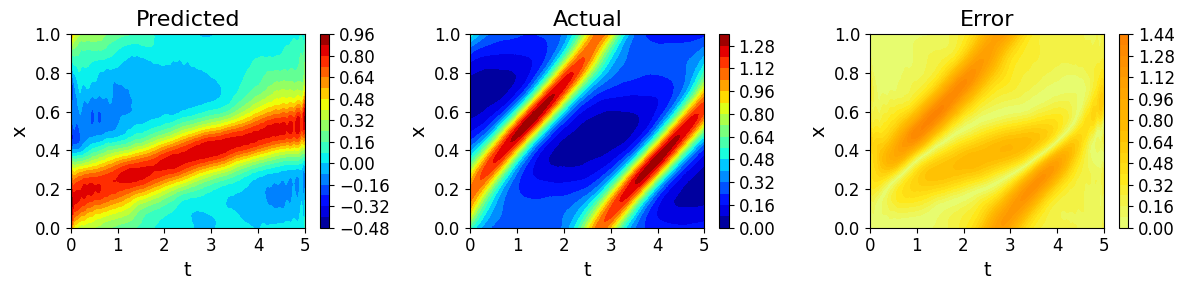

In [70]:
error = np.abs(pred_FNO_ - output_FNO_)

plt.figure(figsize = (12,3))
    
plt.subplot(1,3,1)
contour1 = plt.contourf(tspan, xspan, pred_FNO_[idx, :, :].T, levels = 20, cmap = 'jet')
cbar1 = plt.colorbar()
cbar1.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Predicted", fontsize = 16)

plt.subplot(1,3,2)
contour2 = plt.contourf(tspan, xspan, output_FNO_[idx, :, :].T, levels = 20, cmap = 'jet')
cbar2 = plt.colorbar()
cbar2.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Actual", fontsize = 16)


plt.subplot(1,3,3)
contour3 = plt.contourf(tspan, xspan, error[idx, :, :].T, levels = 20, cmap = 'Wistia')
cbar3 = plt.colorbar()
cbar3.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Error", fontsize = 16)

plt.tight_layout()
# plt.savefig(filepath + f"/Contour_plots_sidx{i}.jpeg", dpi = 800)
plt.show()

In [71]:
auto_reg_error = []

for i in range(Nt):
    err = np.linalg.norm(pred_FNO_[:,i,:] - output_FNO_[:,i,:])/np.linalg.norm(output_FNO_[:,i,:])
    auto_reg_error.append(err)

In [72]:
print("----Extrapolation errors----")
#Compute statistics
t = [120, 140, 160, 200]

for t_idx in t:
    print(f"t: {t_idx}, L2 error: {auto_reg_error[t_idx-1]}")

----Extrapolation errors----
t: 120, L2 error: 0.9649988412857056
t: 140, L2 error: 0.872749924659729
t: 160, L2 error: 0.7897295951843262
t: 200, L2 error: 0.7278066277503967


In [18]:
save=True
if save:
    np.save(result_dir + "/auto_reg_error_FNO2D_FR.npy", auto_reg_error)

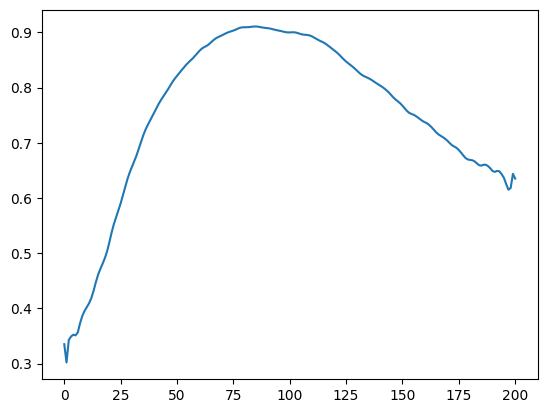

In [19]:
plt.plot(auto_reg_error)
plt.show()

In [20]:
save_arr = True
if save_arr:
    np.save("FNO_full_rollout/u_pred.npy", pred_FNO_)
    np.save("FNO_full_rollout/u_actual.npy", output_FNO_)

In [ ]:
# Get the representative sample plots for u(x, t= 0.25), u(x, t=0.5), u(x, t=0.75), u(x, t= 1.0)
u_pred = pred_FNO_
output = output_FNO_

sample_idx = 491


# sample_idx = 70
time_steps_idx = [50, 100, 140, 170, 200]
x_test = jnp.linspace(0,10,100)
print(f"Sample Idx being considered: {sample_idx}")

plt.figure(figsize=(12, 2.85))  # wider figure for 1x4 layout

for idx, i in enumerate(time_steps_idx):
    plt.subplot(1, 5, idx + 1)
    plt.plot(x_test, u_pred[sample_idx, i, :], label="Predicted",
             color="red", marker='o', markersize=1, linestyle='--')
    plt.plot(x_test, output[sample_idx, i, :], label="Actual",
             color="blue", marker='o', markersize=1, linestyle='-')
    # plt.xlabel("x", fontsize=14)
    # plt.title(f"t = {(i+1) * 0.025:.2f}", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.gca().set_xticklabels([])
    
    # plt.ylim(0.005, 0.9)

    plt.tick_params(axis="both", which="major", length=6, direction="in")
    plt.tick_params(axis="both", which="minor", length=3.5, direction="in")
    plt.minorticks_on()

    plt.grid(which="major", axis="both", alpha=0.6, linestyle='-')
    plt.grid(which="minor", axis="both", alpha=0.3, linestyle='--')

    if idx == 0:  # Only add the y-axis label and legend to the first subplot
        plt.ylabel("u(x, t)", fontsize=14)
        # plt.legend(fontsize=12)
    else:
        plt.gca().set_yticklabels([])

plt.tight_layout()
plt.savefig(result_dir + "/KdV_u_xt_subplot.jpeg", dpi=800)
plt.show()